# Amazon Sales Analysis using Python

## Objective

The objective of this project is to analyze Amazon sales data using Python and identify trends in revenue, profitability, product performance, customer behavior, and shipping efficiency.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib

## Dataset

- Orders
- Products
- Customers
- Revenue
- Profit

#====================================
# IMPORT LIBRARIES
#====================================

In [507]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
pd.set_option("Display.max_columns",None)
pd.set_option('display.float_format', '{:,.2f}'.format)

#=============================
# LOAD DATASET
#=============================

In [508]:
df = pd.read_excel(r"C:\Users\jatin\Downloads\Amazon Data.xlsx")

#=================================
# BASIC INSPECTION
#=================================

In [509]:
print("="*60)
print("DATA TYPES")
display(df.head())

print("="*60)
print("FIRST 5 ROWS")
display(df.tail())

print("="*60)
print("RANDOM 5 ROWS")
display(df.sample(5))

print("="*60)
print("DATASET SHAPE")
print(df.shape)

print("="*60)
print("COLUMN NAMES")
display(pd.DataFrame(df.columns,columns=["Columns"]))

DATA TYPES


,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,6.87
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,14.17
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.28,4,1.97
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.15,4,90.72
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3,5.78


FIRST 5 ROWS


,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
3198,CA-2013-125794,2013-09-30,2013-10-04,MarisLaWare@gmail.com,"United States,Los Angeles,California",Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.24,1,15.22
3199,CA-2014-121258,2014-02-27,2014-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.96,2,15.63
3200,CA-2014-121258,2014-02-27,2014-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Phones,Aastra 57i VoIP phone,258.58,2,19.39
3201,CA-2014-121258,2014-02-27,2014-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4,13.32
3202,CA-2014-119914,2014-05-05,2014-05-10,ChrisCortes@gmail.com,"United States,Westminster,California",Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.16,2,72.95


RANDOM 5 ROWS


,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
2964,CA-2013-126732,2013-09-03,2013-09-07,LenaRadford@gmail.com,"United States,Los Angeles,California",Art,Blackstonian Pencils,18.69,7,5.23
881,CA-2013-144729,2013-10-22,2013-10-26,JoelEaton@gmail.com,"United States,San Diego,California",Storage,"Belkin 19"" Vented Equipment Shelf, Black",154.44,3,1.54
608,CA-2011-164721,2011-11-25,2011-11-27,LaurelWorkman@gmail.com,"United States,Brentwood,California",Appliances,Belkin F9G930V10-GRY 9 Outlet Surge,320.88,6,93.06
2815,CA-2014-128076,2014-02-03,2014-02-08,BillOverfelt@gmail.com,"United States,San Diego,California",Furnishings,Eldon Antistatic Chair Mats for Low to Medium ...,210.58,2,12.63
1242,CA-2011-103940,2011-09-17,2011-09-21,BradleyNguyen@gmail.com,"United States,Seattle,Washington",Furnishings,"Executive Impressions 12"" Wall Clock",35.34,2,13.43


DATASET SHAPE
(3203, 10)
COLUMN NAMES


,Columns
0,Order ID
1,Order Date
2,Ship Date
3,EmailID
4,Geography
5,Category
6,Product Name
7,Sales
8,Quantity
9,Profit


# Data Dictionary
|Column  |  Description|
|--------|-------------|
|Order ID| Unique Order ID|
|Order Date | Order Date |
|Ship Date | Shipping Date |
|Email ID | Customer Email |
|Geography | Customer Location |
|Category | Product Category |
|Product Name | Product Name |
|Revenue | Sales Amount |
|Quantity | Units Sold |
|Profit | Profit Earned |
|Order Year | Order Year |
|Month Number | Month Number of Order
|Month | Month Name of Order |
|Quarter | Sales in Quarter |
|Day Name | Name of Day |
|Day Type | Day Type |
|Shipping Days | Days in Shipping  Order|
|Shipping Speed | Speed of Order |
|Profit Margin % | Percentage of Profit |
|Sales Category | Category of Sales |
|Season | Season in Sell |
|Year | Year |
|Month | Order Month |
|Sales per Quantity | Sales per Quantity |
|Profit per Quantity | Profit Per Quantity |
|Profit Status | Status of Profit |
|Customers Orders Count| Count of Customer Order |
    

In [510]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   object        
 1   Order Date    3203 non-null   datetime64[ns]
 2   Ship Date     3203 non-null   datetime64[ns]
 3   EmailID       3203 non-null   object        
 4   Geography     3203 non-null   object        
 5   Category      3203 non-null   object        
 6   Product Name  3203 non-null   object        
 7   Sales         3203 non-null   float64       
 8   Quantity      3203 non-null   int64         
 9   Profit        3203 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 250.4+ KB


In [511]:
df.describe(include='object')

,Order ID,EmailID,Geography,Category,Product Name
count,3203,3203,3203,3203,3203
unique,1611,686,170,17,1494
top,CA-2013-165330,WilliamBrown@gmail.com,"United States,Los Angeles,California",Binders,Staples
freq,11,24,747,471,60


In [512]:
df.describe(include='object')

,Order ID,EmailID,Geography,Category,Product Name
count,3203,3203,3203,3203,3203
unique,1611,686,170,17,1494
top,CA-2013-165330,WilliamBrown@gmail.com,"United States,Los Angeles,California",Binders,Staples
freq,11,24,747,471,60


# Dataset Summary

- Total Rows:
- Total Columns:
- Duplicate Rows:
- Missing Values:

In [513]:
print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

print("Duplicate Rows :",df.duplicated().sum())

print("Missing Values :",df.isnull().sum().sum())

Rows : 3203
Columns : 10
Duplicate Rows : 0
Missing Values : 0


#=============================
# MISSING VALUES
#=============================

In [514]:
df.isnull().sum()

Order ID        0
Order Date      0
Ship Date       0
EmailID         0
Geography       0
Category        0
Product Name    0
Sales           0
Quantity        0
Profit          0
dtype: int64

In [515]:
(df.isnull().sum()/len(df))*100

Order ID       0.00
Order Date     0.00
Ship Date      0.00
EmailID        0.00
Geography      0.00
Category       0.00
Product Name   0.00
Sales          0.00
Quantity       0.00
Profit         0.00
dtype: float64

#===============================
# DUPLICATED RECORD
#===============================

In [516]:
df.duplicated().sum()

np.int64(0)

#=======================
# DATA TYPES
#=======================

In [517]:
df.dtypes

Order ID                object
Order Date      datetime64[ns]
Ship Date       datetime64[ns]
EmailID                 object
Geography               object
Category                object
Product Name            object
Sales                  float64
Quantity                 int64
Profit                 float64
dtype: object

#===============================
# UNIQUE VALUES
#===============================

In [518]:
df.nunique()

Order ID        1611
Order Date       845
Ship Date        911
EmailID          686
Geography        170
Category          17
Product Name    1494
Sales           2348
Quantity          14
Profit          2614
dtype: int64

In [519]:
df['Category'].unique()

array(['Labels', 'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances',
       'Tables', 'Storage', 'Accessories', 'Paper', 'Chairs', 'Fasteners',
       'Supplies', 'Envelopes', 'Copiers', 'Bookcases', 'Machines'],
      dtype=object)

#=====================================
# DATA CLEANING
#=====================================

In [520]:
df.columns = df.columns.str.strip() 

#==========================
# RENAME COLUMNS
#==========================

In [521]:
df.rename(columns={
    'Sales':'Revenue'
}, inplace=True)

In [522]:
print("Negative Profit Orders :",(df['Profit']<0).sum())


Negative Profit Orders : 318


In [523]:
print("Zero Revenue Orders :",(df['Revenue'] ==0).sum())

Zero Revenue Orders : 0


#===========================
# HELPER COLUMNS
#===========================

In [524]:
df['Order Year'] = df['Order Date'].dt.year

In [525]:
df['Month Number'] = df['Order Date'].dt.month

In [526]:
df['Month'] = df['Order Date'].dt.month_name()

In [527]:
df['Quarter'] = df['Order Date'].dt.quarter.astype(str)


In [528]:
df['Day'] = df['Order Date'].dt.day

In [529]:
df['Day Name'] = df['Order Date'].dt.day_name()

In [530]:
df['Day Type'] = np.where(
    df['Order Date'].dt.weekday>=5,
    'Weekend',
    'Weekday'
)

In [531]:
df['Shipping Days'] = (
    df['Ship Date'] - 
    df['Order Date']
).dt.days

In [532]:
df['Shipping Speed'] = np.where(
    df['Shipping Days']<=2,
    'Fast',
    np.where(
        df['Shipping Days']<=5,
        'Medium',
        'Slow'
    )
)
    

In [533]:
df['Profit Margin %'] =(
    df['Profit']/df['Revenue']
)*100

In [534]:
df['Sales Category'] = pd.cut(
    df['Revenue'],
    bins=[0,100,500,1000,float('inf')],
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [535]:
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else: 
        return "Automn"
df['Season'] = df['Order Date'].dt.month.apply(season)

In [536]:
df['Year Month'] = df['Order Date'].dt.strftime('%Y-%m')


In [537]:
df['Sales per Quantity'] = (
    df['Revenue']/df['Quantity']
)

In [538]:
df['Profit per Quantity'] = (
    df['Profit']/df['Quantity']
)

In [539]:
df['Profit Status'] = np.where(
    df['Profit']>0,
    'Profit',
    'Loss'
)

In [540]:
df['Customer Order Count'] = (
    df.groupby('EmailID')['Order ID']
.transform('count')
)

In [541]:
df[['Country','City','State']] = df['Geography'].str.split(',',expand=True)

df['Country'] = df['Country'].str.strip()
df['City'] = df['City'].str.strip()
df['State'] = df['State'].str.strip()

# FEATURE ENGINEERING
### Helper Columns Created

✔ Order Year

✔ Order Month

✔ Order Month Number

✔ Quarter

✔ Order Day

✔ Order Day Name

✔ Day Type

✔ Shipping Days

✔ Shipping Speed

✔ Profit Margin %

✔ Sales Category

✔ Profit Category

✔ Season

✔ Year Month

✔ Customer Order Count

✔ Sales per Quantity

✔ Profit per Quantity

✔ State

✔ City

✔ Country


#===================================
# EXPLORATORY DATA ANALYSIS
#===================================

In [542]:
df.describe()

,Order Date,Ship Date,Revenue,Quantity,Profit,Order Year,Month Number,Day,Shipping Days,Profit Margin %,Sales per Quantity,Profit per Quantity,Customer Order Count
count,3203,3203,"3,203.00","3,203.00","3,203.00","3,203.00","3,203.00","3,203.00","3,203.00","3,203.00","3,203.00","3,203.00","3,203.00"
mean,2013-05-10 03:06:07.530440192,2013-05-14 01:25:25.195129600,226.49,3.83,33.85,"2,012.73",8.03,15.99,3.93,21.95,60.72,9.19,7.14
min,2011-01-07 00:00:00,2011-01-09 00:00:00,0.99,1.00,"-3,399.98","2,011.00",1.00,1.00,0.00,-210.00,0.54,-680.00,1.00
25%,2012-05-22 00:00:00,2012-05-26 00:00:00,19.44,2.00,3.85,"2,012.00",5.00,9.00,3.00,10.00,6.34,1.40,4.00
50%,2013-07-22 00:00:00,2013-07-25 00:00:00,60.84,3.00,11.17,"2,013.00",9.00,16.00,4.00,29.00,18.34,3.23,7.00
75%,2014-05-23 00:00:00,2014-05-27 00:00:00,215.81,5.00,33.00,"2,014.00",11.00,23.00,5.00,37.50,63.97,9.48,9.00
max,2014-12-31 00:00:00,2015-01-06 00:00:00,"13,999.96",14.00,"6,719.98","2,014.00",12.00,31.00,7.00,50.00,"3,499.99","1,680.00",24.00
std,NaN,NaN,524.88,2.26,174.11,1.14,3.25,8.63,1.81,27.98,132.67,42.96,4.22


In [543]:
df.corr(numeric_only=True)

,Revenue,Quantity,Profit,Order Year,Month Number,Day,Shipping Days,Profit Margin %,Sales per Quantity,Profit per Quantity,Customer Order Count
Revenue,1.00,0.21,0.65,0.01,-0.03,0.01,-0.02,-0.11,0.88,0.61,-0.03
Quantity,0.21,1.00,0.09,0.01,0.01,-0.00,0.05,-0.03,-0.02,-0.01,0.01
Profit,0.65,0.09,1.00,0.02,-0.03,0.01,-0.03,0.22,0.60,0.94,-0.01
Order Year,0.01,0.01,0.02,1.00,-0.05,-0.05,-0.04,-0.00,0.01,0.01,-0.04
Month Number,-0.03,0.01,-0.03,-0.05,1.00,-0.10,-0.03,-0.03,-0.04,-0.03,0.08
Day,0.01,-0.00,0.01,-0.05,-0.10,1.00,0.00,0.00,0.01,0.01,0.06
Shipping Days,-0.02,0.05,-0.03,-0.04,-0.03,0.00,1.00,-0.02,-0.04,-0.04,0.00
Profit Margin %,-0.11,-0.03,0.22,-0.00,-0.03,0.00,-0.02,1.00,-0.11,0.23,0.00
Sales per Quantity,0.88,-0.02,0.60,0.01,-0.04,0.01,-0.04,-0.11,1.00,0.67,-0.02
Profit per Quantity,0.61,-0.01,0.94,0.01,-0.03,0.01,-0.04,0.23,0.67,1.00,-0.01


In [544]:
df.nunique()

Order ID                1611
Order Date               845
Ship Date                911
EmailID                  686
Geography                170
Category                  17
Product Name            1494
Revenue                 2348
Quantity                  14
Profit                  2614
Order Year                 4
Month Number              12
Month                     12
Quarter                    4
Day                       31
Day Name                   7
Day Type                   2
Shipping Days              8
Shipping Speed             3
Profit Margin %          249
Sales Category             4
Season                     4
Year Month                48
Sales per Quantity      1482
Profit per Quantity     1793
Profit Status              2
Customer Order Count      20
Country                    1
City                     169
State                     11
dtype: int64

In [545]:
df['Category'].value_counts()

Category
Binders        471
Paper          450
Furnishings    304
Phones         277
Storage        266
Accessories    258
Art            250
Chairs         207
Appliances     136
Labels         116
Tables         116
Bookcases       80
Fasteners       72
Supplies        69
Envelopes       67
Machines        39
Copiers         25
Name: count, dtype: int64

# Business Questions

The following analysis answers important business questions using Python and Pandas.

In [546]:
# Total Revenue
df['Revenue'].sum()

np.float64(725457.8245)

In [547]:
# Total Profit
df['Profit'].sum()

np.float64(108418.4489)

In [548]:
# Average Revenue
df['Revenue'].mean()

np.float64(226.49323275054635)

In [549]:
# Average Profit
df['Profit'].mean()

np.float64(33.84903181392445)

In [550]:
# Revenue By Category
df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

Category
Chairs        101,781.33
Phones         98,684.35
Tables         84,754.56
Storage        70,532.85
Accessories    61,114.12
Binders        55,961.11
Copiers        49,749.24
Machines       42,444.12
Bookcases      36,004.12
Appliances     30,236.34
Furnishings    30,072.73
Paper          26,663.72
Supplies       18,127.12
Art             9,212.07
Labels          5,078.73
Envelopes       4,118.10
Fasteners         923.22
Name: Revenue, dtype: float64

In [551]:
# Profit by Category
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Copiers       19,327.24
Accessories   16,484.60
Binders       16,096.80
Paper         12,119.24
Phones         9,110.74
Storage        8,645.32
Appliances     8,261.27
Furnishings    7,641.27
Chairs         4,027.58
Art            2,374.10
Labels         2,303.12
Envelopes      1,908.76
Tables         1,482.61
Supplies         626.05
Fasteners        275.19
Machines        -618.93
Bookcases     -1,646.51
Name: Profit, dtype: float64

In [552]:
# Revenue by Goegraphy
df.groupby('Geography')['Revenue'].sum()

Geography
United States,Albuquerque,New Mexico    2,220.16
United States,Anaheim,California        7,986.87
United States,Antioch,California           19.44
United States,Apple Valley,California   1,915.08
United States,Arvada,Colorado             503.40
                                          ...   
United States,Westminster,California    3,826.65
United States,Whittier,California         444.77
United States,Woodland,California         264.66
United States,Yucaipa,California           50.80
United States,Yuma,Arizona                840.87
Name: Revenue, Length: 170, dtype: float64

In [553]:
# Profit By Geography
df.groupby('Geography')['Profit'].sum()

Geography
United States,Albuquerque,New Mexico      634.09
United States,Anaheim,California        1,234.00
United States,Antioch,California            9.33
United States,Apple Valley,California     283.62
United States,Arvada,Colorado              59.86
                                          ...   
United States,Westminster,California      763.69
United States,Whittier,California          44.48
United States,Woodland,California          33.38
United States,Yucaipa,California           13.21
United States,Yuma,Arizona               -465.99
Name: Profit, Length: 170, dtype: float64

In [554]:
# Monthly Revenue
df.groupby('Month')['Revenue'].sum().sort_values(ascending=False)

Month
December    115,934.54
November     93,068.82
September    81,618.46
March        73,023.74
July         64,706.89
August       62,674.33
October      57,436.80
June         48,519.55
May          45,320.87
April        41,966.58
January      24,918.62
February     16,268.61
Name: Revenue, dtype: float64

In [555]:
# Yearly Revenue
df.groupby('Order Year')['Revenue'].sum()

Order Year
2011   147,883.03
2012   139,966.25
2013   186,976.02
2014   250,632.53
Name: Revenue, dtype: float64

In [556]:
# Top Customers
df.groupby('EmailID')['Revenue'].sum().sort_values(ascending=False).head(10)

EmailID
RaymondBuch@gmail.com     14,345.28
KenLonsdale@gmail.com      8,472.39
EdwardHooks@gmail.com      7,447.77
JaneWaco@gmail.com         7,391.53
KarenFerguson@gmail.com    7,182.77
NickCrebassa@gmail.com     6,734.23
ClayLudtke@gmail.com       6,069.64
YanaSorensen@gmail.com     5,754.17
NoraPreis@gmail.com        5,564.60
WilliamBrown@gmail.com     5,523.05
Name: Revenue, dtype: float64

In [557]:
# Lowest Profit Products
df.groupby('Product Name')['Revenue'].sum().sort_values().head(10)

Product Name
Colored Push Pins                              1.81
Wilson Jones DublLock D-Ring Binders           2.02
Acco Banker's Clasps, 5 3/4"-Long              2.88
Bagged Rubber Bands                            3.02
Avery 511                                      3.08
Avery 510                                      3.75
Design Ebony Sketching Pencil                  4.17
Acco Economy Flexible Poly Round Ring Binder   4.18
Avery Round Ring Poly Binders                  4.54
Sterling Rubber Bands by Alliance              4.71
Name: Revenue, dtype: float64

In [558]:
# Top Products
df.groupby('Product Name')['Revenue'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                         13,999.96
High Speed Automatic Electric Letter Opener                                   13,100.24
Global Troy Executive Leather Low-Back Tilter                                 10,019.60
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    8,134.34
GuestStacker Chair with Chrome Finish Legs                                     8,030.02
Okidata MB760 Printer                                                          7,834.40
Bretford Rectangular Conference Table Tops                                     7,710.66
LogitechÂ P710e Mobile Speakerphone                                            7,467.21
Canon PC1060 Personal Laser Copier                                             6,719.90
Hewlett Packard LaserJet 3310 Copier                                           6,239.90
Name: Revenue, dtype: float64

In [559]:
# Season Wise Performance
df.groupby('Season')['Revenue'].sum().sort_values(ascending=False)

Season
Monsoon   257,519.23
Summer    160,311.20
Winter    157,121.78
Automn    150,505.62
Name: Revenue, dtype: float64

In [560]:
# Max Revenue 
df['Revenue'].max()

np.float64(13999.96)

In [561]:
# Min Revenue
df['Revenue'].min()

np.float64(0.99)

In [562]:
df['Revenue'].median()

np.float64(60.84)

# Data Visualization

The following charts help understand revenue, profit, customer behaviour and product performance.

#Revenue Distribution

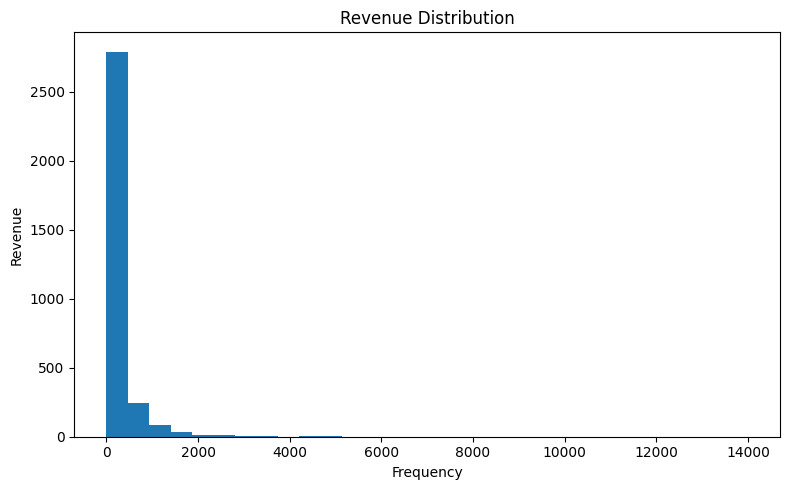

In [563]:
plt.figure(figsize=(8,5))
plt.hist(df['Revenue'],bins=30)
plt.title("Revenue Distribution")
plt.ylabel("Revenue")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

## Insight

The revenue distribution is positively skewed, indicating that most orders generate relatively low revenue while a small number of orders contribute significantly higher sales.

## Recommendation

Focus on increasing the average order value through product bundles and upselling strategies.

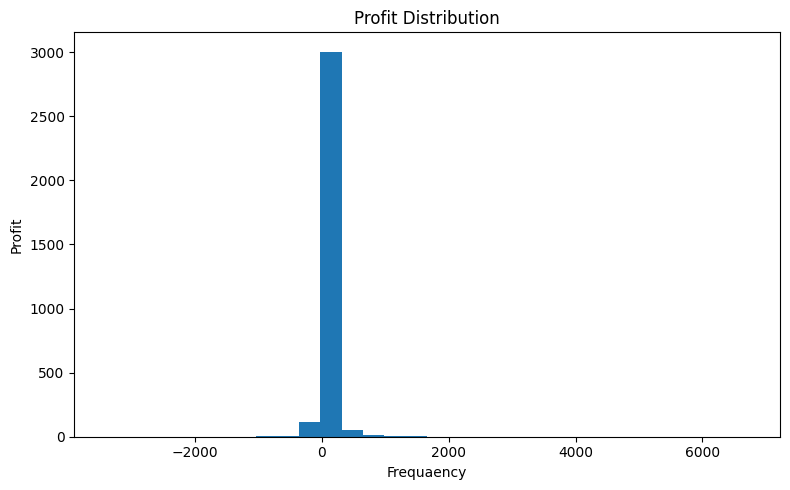

In [564]:
plt.figure(figsize=(8,5))
plt.hist(df['Profit'],bins=30)
plt.title("Profit Distribution")
plt.ylabel("Profit")
plt.xlabel("Frequaency")
plt.tight_layout()
plt.show()

## Insight

Most orders generate positive profit, while a smaller number of transactions result in low or negative profitability.

## Recommendation

Identify low-profit products and review their pricing or operational costs.

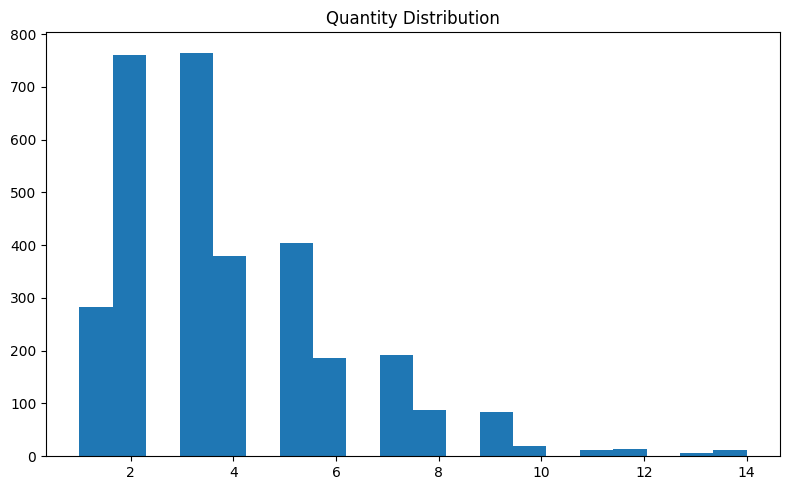

In [565]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'],bins=20)
plt.title("Quantity Distribution")
plt.tight_layout()
plt.show()

## Insight

Most customer orders contain a relatively small number of items, indicating a preference for low-volume purchases.

## Recommendation

Introduce bundle offers and volume discounts to encourage customers to purchase more items per order.

In [566]:
(
    df.groupby('Category')
    .agg(
    Total_Revenue=('Revenue','sum'),
    Average_Revenue=('Revenue','mean'),
    Total_Orders=('Order ID','count')
  )
.sort_values('Total_Revenue',ascending=False)
)

,Total_Revenue,Average_Revenue,Total_Orders
Category,,,
Chairs,"101,781.33",491.70,207
Phones,"98,684.35",356.26,277
Tables,"84,754.56",730.64,116
Storage,"70,532.85",265.16,266
Accessories,"61,114.12",236.88,258
Binders,"55,961.11",118.81,471
Copiers,"49,749.24","1,989.97",25
Machines,"42,444.12","1,088.31",39
Bookcases,"36,004.12",450.05,80


## Insight

The Chairs product category contributes the largest share of overall revenue and is the primary driver of sales.

## Recommendation

Increase inventory and promotional efforts for the highest-performing category while improving the visibility of lower-performing categories.

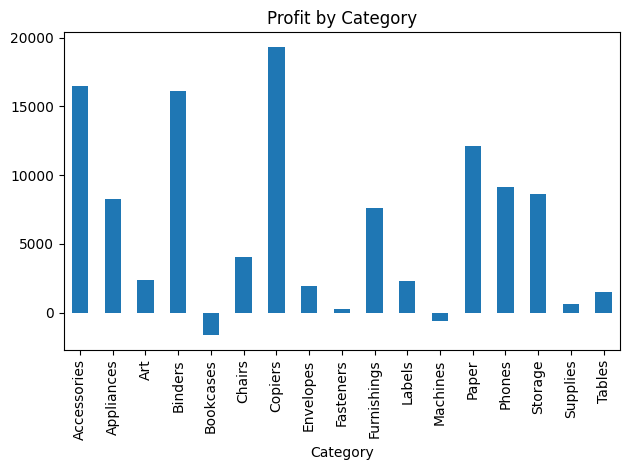

In [567]:
profit = df.groupby('Category')['Profit'].sum()
profit.plot(kind='bar')
plt.title('Profit by Category')
plt.tight_layout()
plt.show()

## Insight

copies generate the highest profit among all categorie  highlighting opportunities to optimize the product mix.

## Recommendation

Prioritize high-margin categories and review pricing strategies for categories with lower profitability.

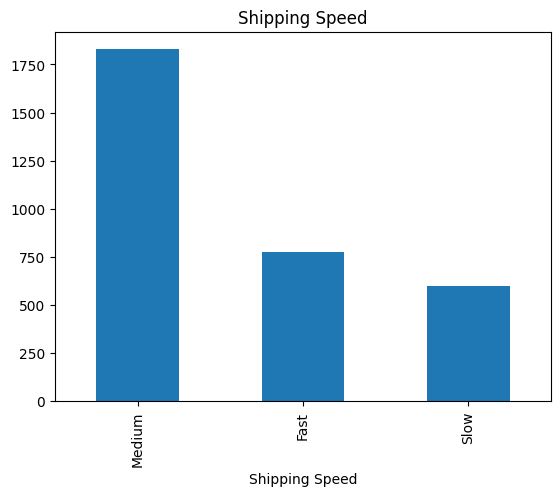

In [568]:
df['Shipping Speed'].value_counts().plot(kind='bar')
plt.title('Shipping Speed')
plt.show()

## Insight

Most orders fall under the Medium shipping category, indicating balanced delivery performance.

## Recommendation

Reduce shipping time where possible to improve customer satisfaction.

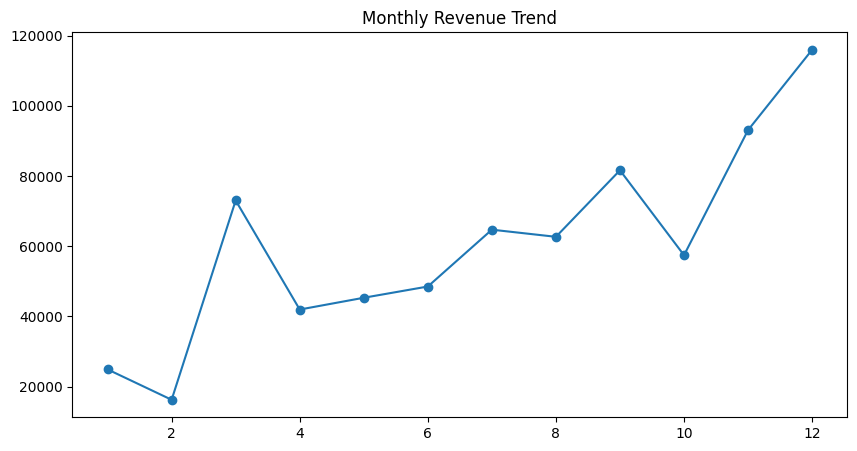

In [569]:
monthly = df.groupby('Month Number')['Revenue'].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly.index,monthly.values,marker='o')
plt.title('Monthly Revenue Trend')
plt.show()

## Insight

Novmber and December is the Peak season , indicating seasonal demand patterns.

## Recommendation

Increase stock levels and marketing efforts before peak revenue months.

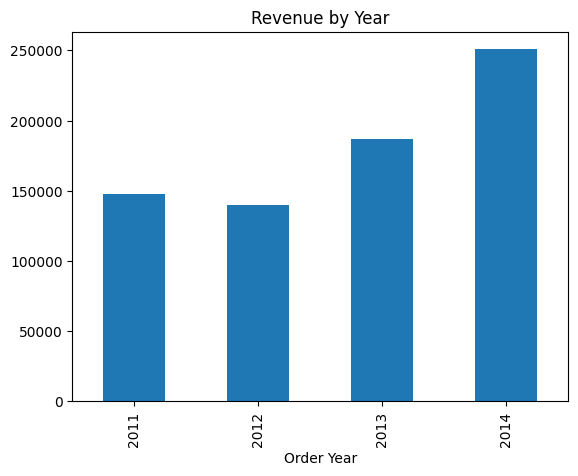

In [570]:
yearly = df.groupby('Order Year')['Revenue'].sum()
yearly.plot(kind='bar')
plt.title('Revenue by Year')
plt.show()

## Insight

Year-over-year revenue indicates overall business growth and customer demand trends.

## Recommendation

Continue strategies that contributed to revenue growth while addressing weaker years.

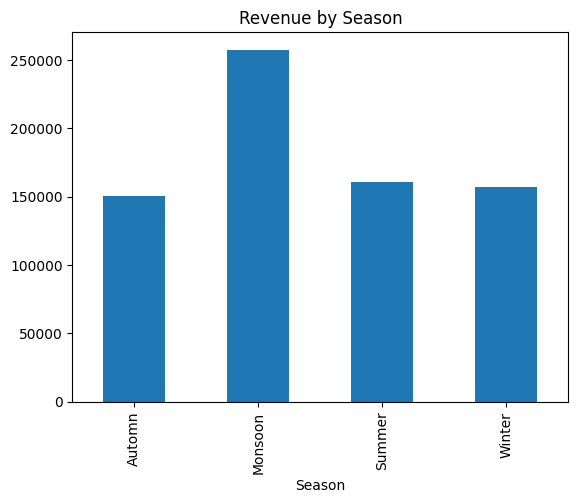

In [571]:
season = df.groupby('Season')['Revenue'].sum()
season.plot(kind='bar')
plt.title('Revenue by Season')
plt.show()

## Insight

Monsoon Season Genrate the highest revenue compare to all season, creating predictable periods of high and low sales.

## Recommendation

Plan inventory and promotional campaigns according to seasonal demand.

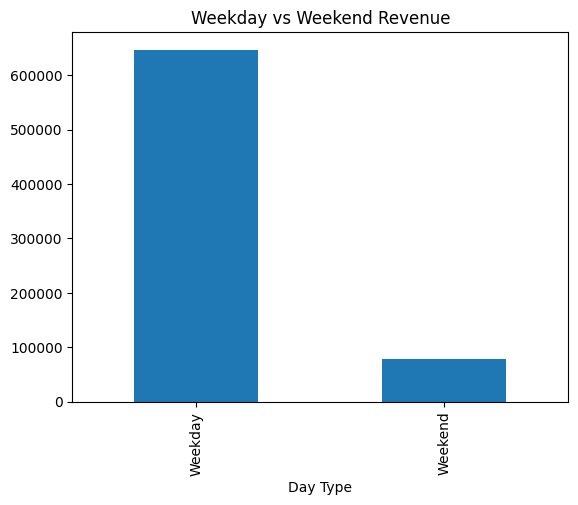

In [572]:
day = df.groupby('Day Type')['Revenue'].sum()
day.plot(kind='bar')
plt.title('Weekday vs Weekend Revenue')
plt.show()

## Insight

Revenue is higher on weekdays than weekends, suggesting stronger customer purchasing activity during the working week.

## Recommendation

Run weekend promotional campaigns to balance sales across the week.

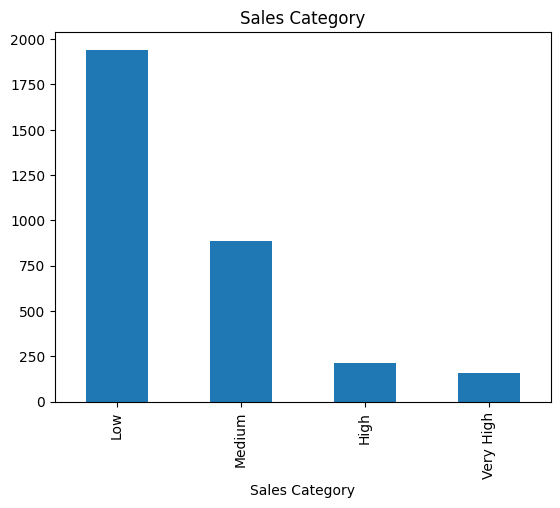

In [573]:
df['Sales Category'].value_counts().plot(kind='bar')
plt.title("Sales Category")
plt.show()

## Insight

Most orders belong to the Low Revenue category, indicating a high number of smaller-value purchases.

## Recommendation

Increase average order value through product bundles and cross-selling.

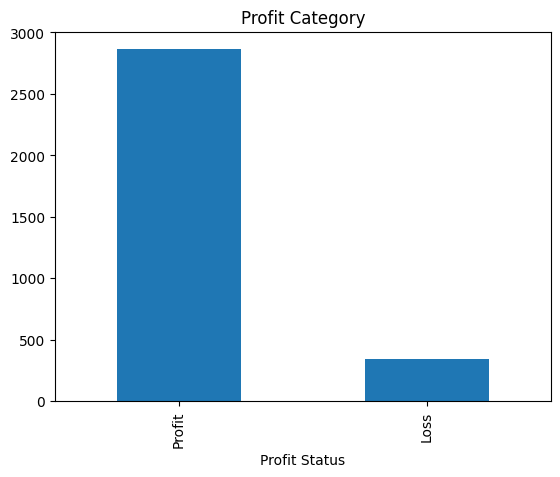

In [574]:
df['Profit Status'].value_counts().plot(kind='bar')
plt.title('Profit Category')
plt.show()

## Insight

The majority of transactions are profitable, demonstrating healthy overall business performance.

## Recommendation

Investigate loss-making orders to identify opportunities for improving margins.

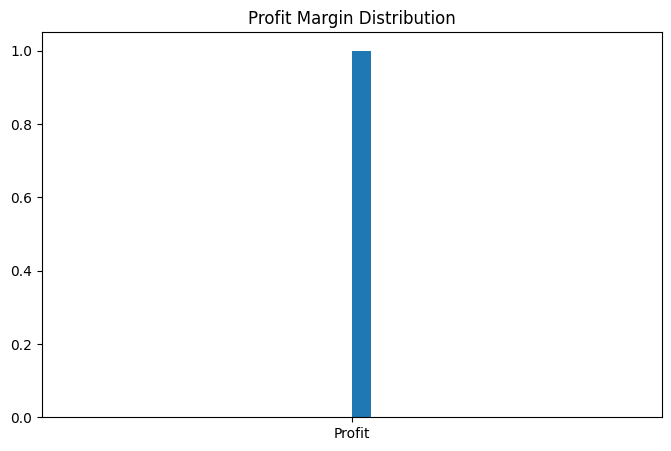

In [575]:
plt.figure(figsize=(8,5))
plt.hist(['Profit'],bins=30)
plt.title('Profit Margin Distribution')
plt.show()

## Insight

Most products maintain a moderate profit margin, while only a few achieve exceptionally high margins.

## Recommendation

Focus sales efforts on products with consistently strong profit margins.

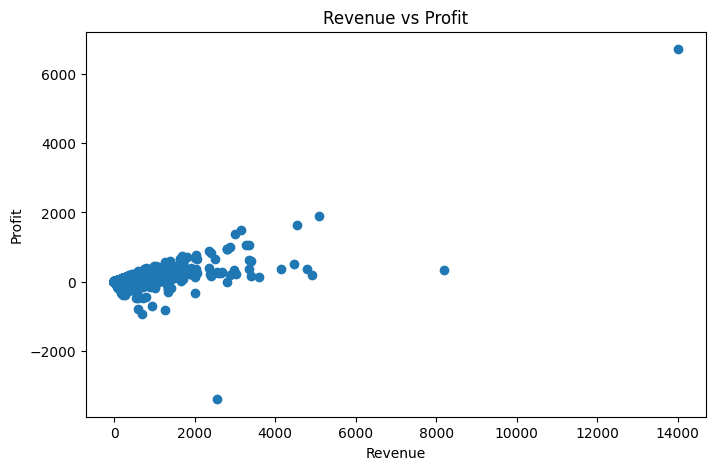

In [576]:
plt.figure(figsize=(8,5))
plt.scatter(df['Revenue'],df['Profit'])
plt.title('Revenue vs Profit')
plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.show()

## Insight

Higher revenue generally leads to higher profit, although some high-revenue orders generate relatively low profit.

## Recommendation

Monitor products with high sales but low margins to improve overall profitability.

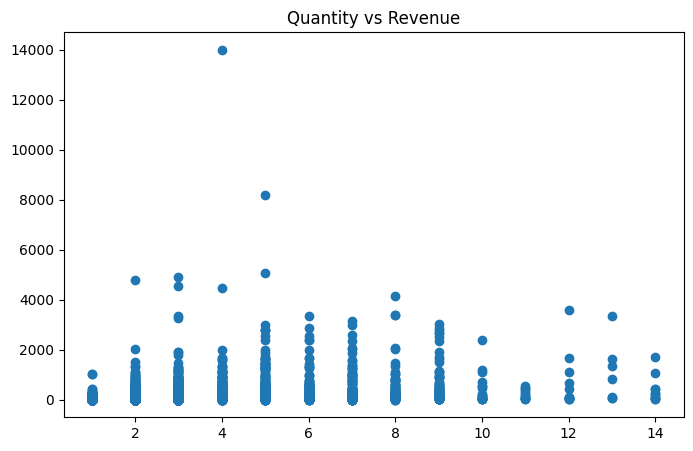

In [577]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'],df['Revenue'])
plt.title('Quantity vs Revenue')
plt.show()

## Insight

Orders containing more items generally generate higher revenue.

## Recommendation

Encourage customers to purchase multiple products through volume discounts and bundle offers.

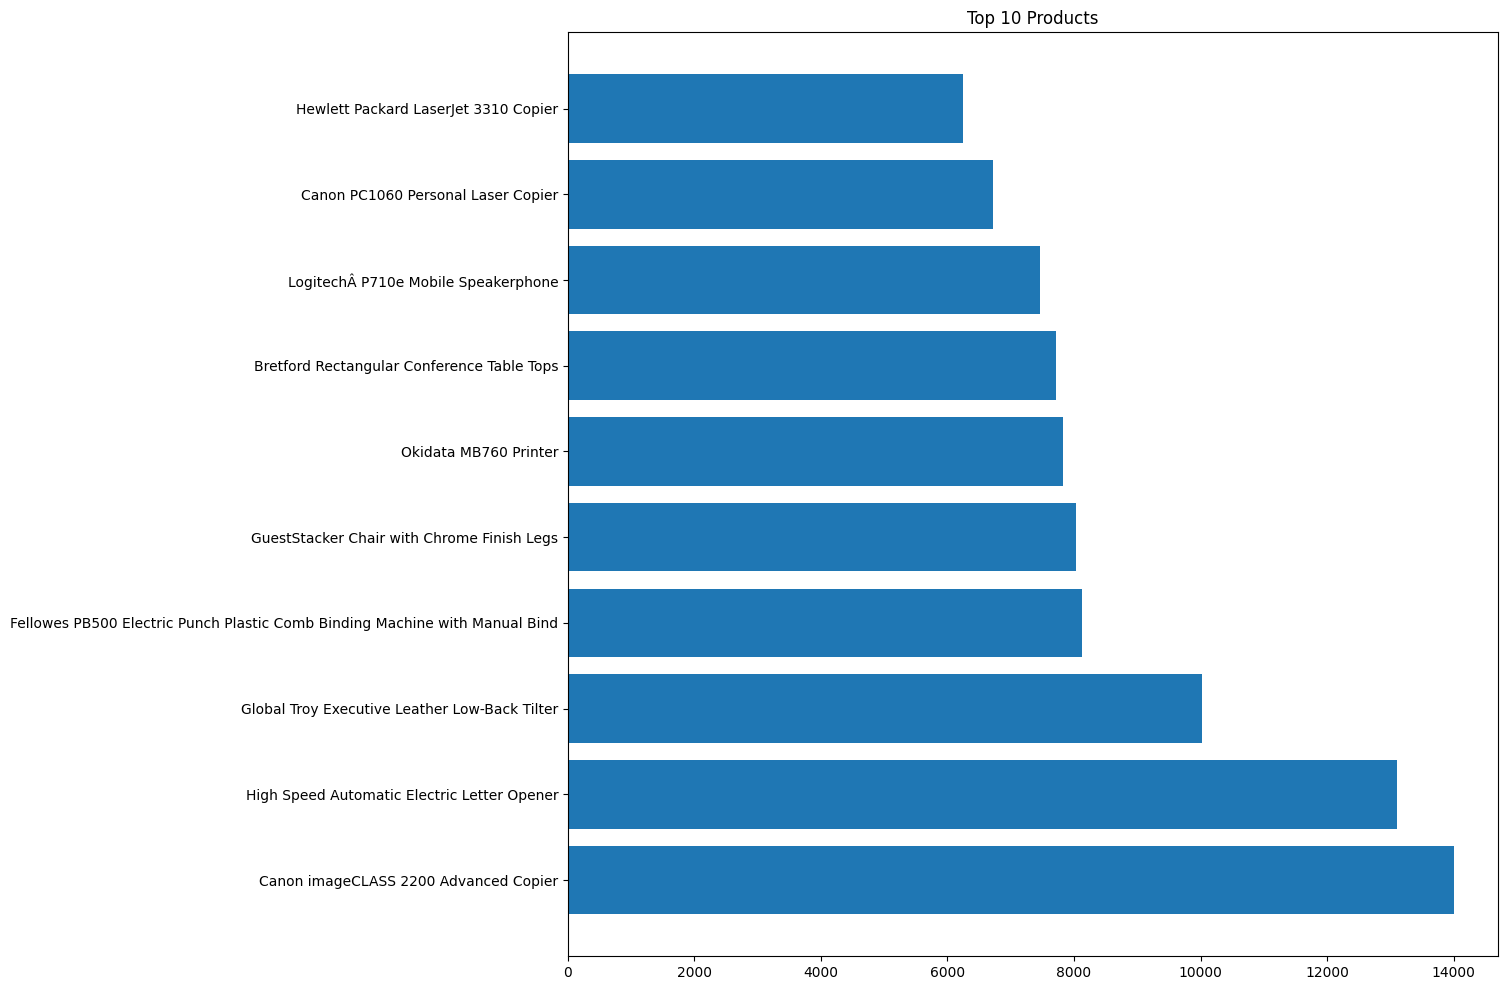

In [589]:
product = df.groupby('Product Name')['Revenue'].sum().nlargest(10)
plt.figure(figsize=(12,12))
plt.barh(product.index,product.values)
plt.title('Top 10 Products')
plt.show()

# Insights 
Canon Camera Generates the highest revenue amonth all products

# Recommnedation
Increase inventory levels and prioritize promotional campaigns for Canon Camera products to maximize future revenue.

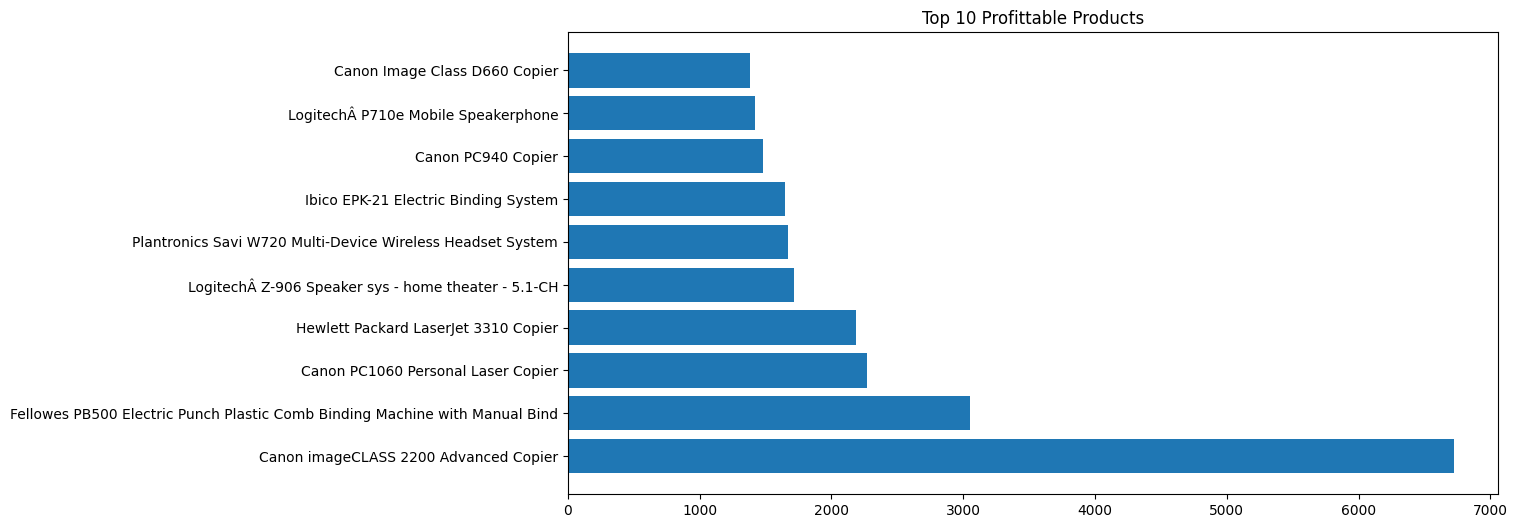

In [579]:
profit = df.groupby('Product Name')['Profit'].sum().nlargest(10)
plt.figure(figsize=(12,6))
plt.barh(profit.index,profit.values)
plt.title("Top 10 Profittable Products")
plt.show()

## Insight

The highest-Profitable product is canon imageclass 2200 copier these product has highest profit among all product

## Recommendation

Maintain sufficient inventory and feature these products prominently in marketing campaigns.

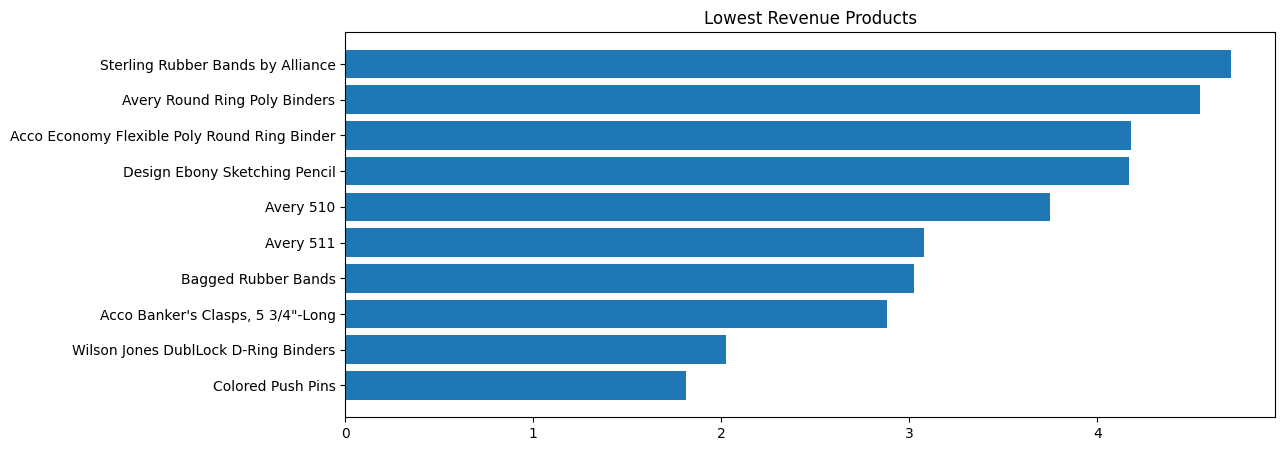

In [580]:
loss = df.groupby('Product Name')['Revenue'].sum().nsmallest(10)
plt.figure(figsize=(12,5))
plt.barh(loss.index,loss.values)
plt.title('Lowest Revenue Products')
plt.show()

## Insight

Rubber band generate low profit despite being part of the product portfolio.

## Recommendation

Review pricing, supplier costs, or discontinue products that remain unprofitable.

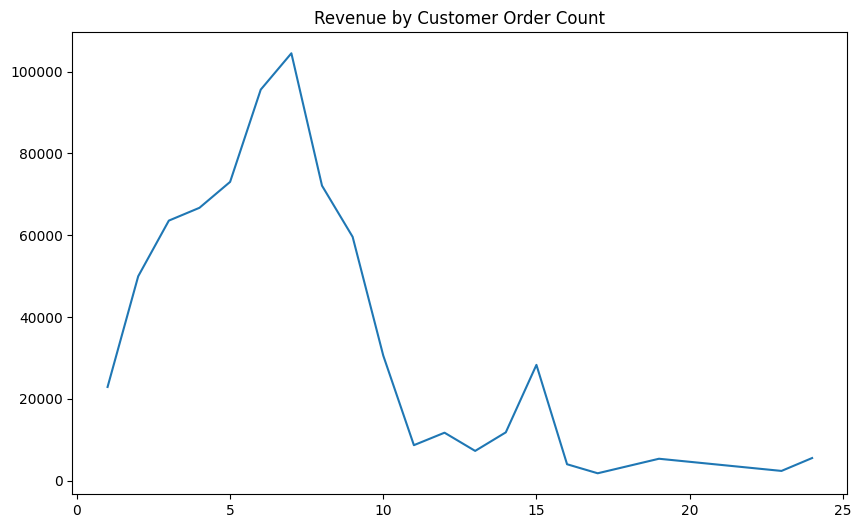

In [581]:
orders = df.groupby('Customer Order Count')['Revenue'].sum()
plt.figure(figsize=(10,6))
plt.plot(orders.index,orders.values)
plt.title('Revenue by Customer Order Count')
plt.show()

## Insight

Customers with multiple purchases contribute substantially to total revenue, highlighting the value of repeat customers.

## Recommendation

Strengthen customer retention strategies through loyalty rewards and personalized communication.

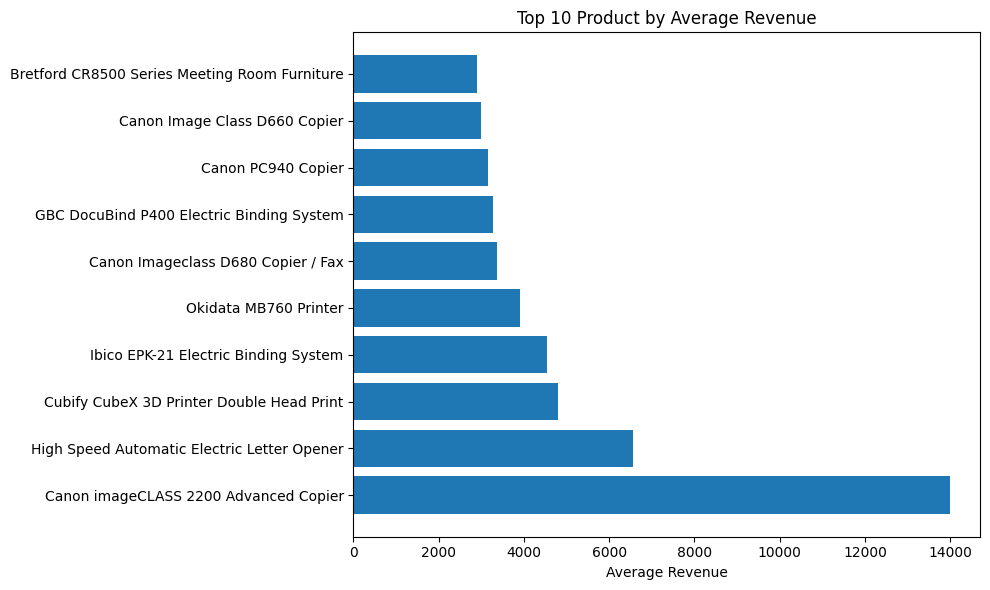

In [582]:
product = df.groupby('Product Name')['Revenue'].mean().nlargest(10)
plt.figure(figsize=(10,6))
plt.barh(product.index,product.values)
plt.title('Top 10 Product by Average Revenue')
plt.xlabel('Average Revenue')
plt.tight_layout()
plt.show()

## Insight

Canon Image Product generate the highest average revenue per transaction, indicating strong customer value.

## Recommendation

Promote these products as premium offerings and maintain consistent stock availability.

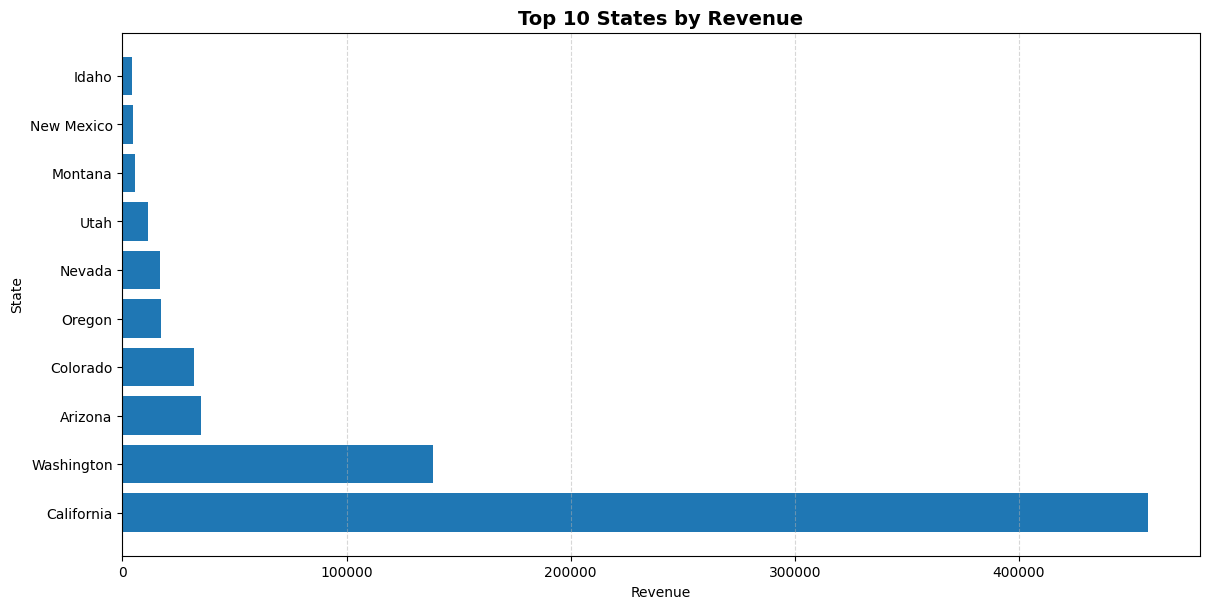

In [583]:
state = (
    df.groupby('State')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
plt.barh(state.index,state.values)
plt.title('Top 10 States by Revenue',fontsize=14,fontweight='bold')
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.xlabel('Revenue')
plt.ylabel('State')
plt.show()

## Insight

California generated the highest total revenue among all states, making it the strongest revenue-contributing market.

## Recommendation

Increase marketing investment and maintain adequate inventory levels in California to maximize future sales.

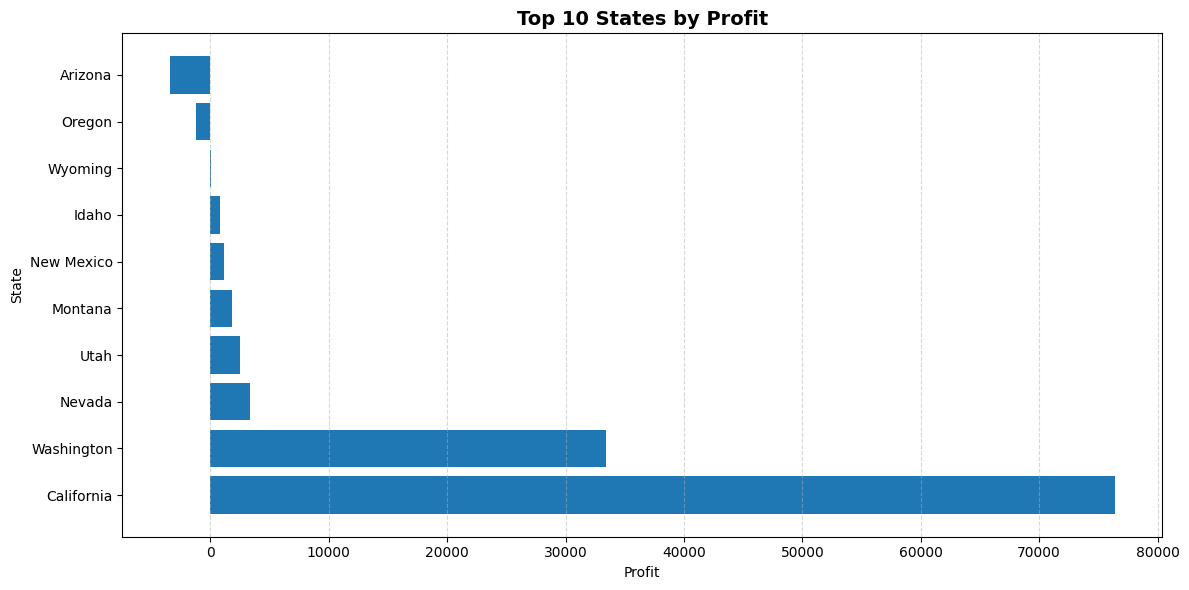

In [584]:
state_profit = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
plt.barh(state_profit.index,state_profit.values)
plt.title('Top 10 States by Profit',fontsize=14,fontweight='bold')
plt.xlabel('Profit')
plt.ylabel('State')
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()


## Insight

California generated the highest total profit among all states, indicating that it is the company's strongest and most profitable regional market.

## Recommendation

Continue investing in California while applying similar strategies to improve profitability in lower-performing states.

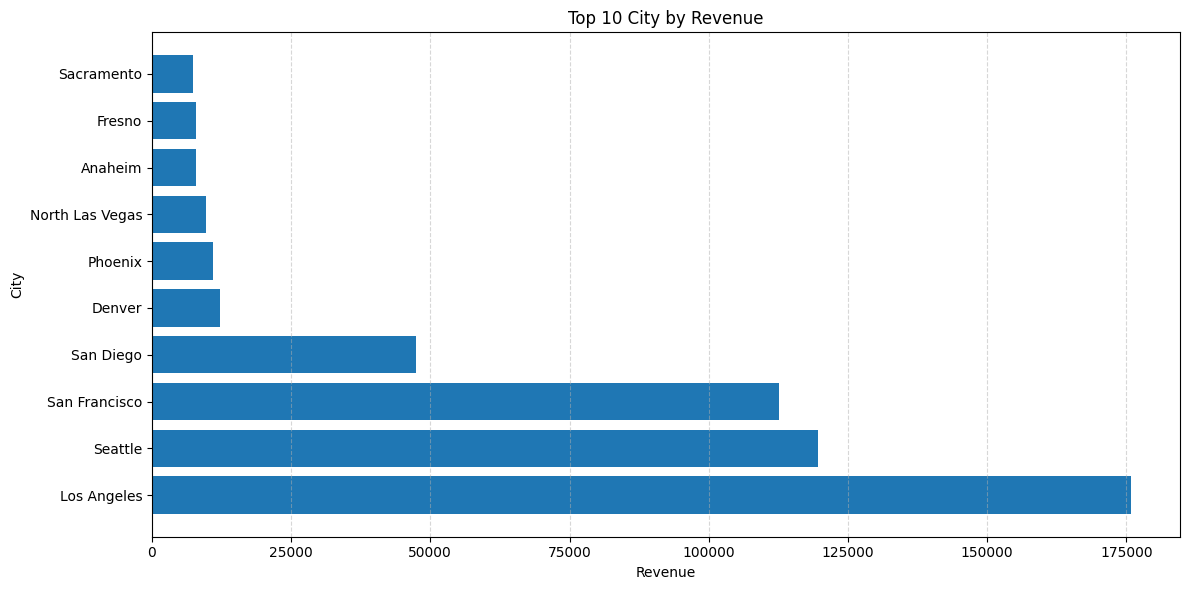

In [585]:
city = (
    df.groupby('City')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
plt.barh(city.index,city.values)
plt.title('Top 10 City by Revenue')
plt.xlabel('Revenue')
plt.ylabel('City')
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

## Insight

Los Angeles generated the highest total revenue among all cities, indicating strong customer demand and market potential.

## Recommendation

Increase marketing efforts and maintain sufficient inventory in Los Angeles to support future revenue growth.


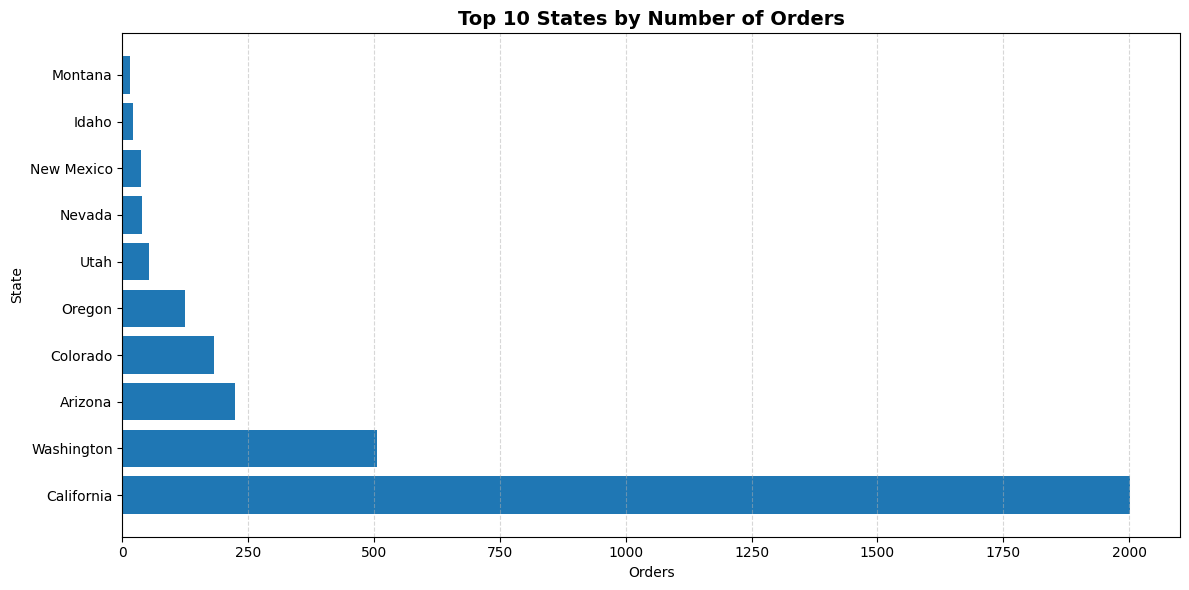

In [586]:
orders = (
    df['State']
    .value_counts()
    .head(10)
)
plt.figure(figsize=(12,6))
plt.barh(orders.index,orders.values)
plt.title('Top 10 States by Number of Orders',fontsize=14,fontweight='bold')
plt.xlabel('Orders')
plt.ylabel('State')
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()


## Insight

California recorded the highest number of customer orders, reflecting strong customer demand and market presence.

## Recommendation

Strengthen customer retention programs and optimize inventory planning to meet future demand.

In [587]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Profit",
        "Average Revenue",
        "Average Profit",
        "Maximum Revenue",
        "Minimum Revenue"
    ],
    "Value": [
        df['Revenue'].sum(),
        df['Profit'].sum(),
        df['Revenue'].mean(),
        df['Profit'].mean(),
        df['Revenue'].max(),
        df['Revenue'].min()
    ]
})

summary["Value"] = summary["Value"].round(2)

summary

,Metric,Value
0,Total Revenue,"725,457.82"
1,Total Profit,"108,418.45"
2,Average Revenue,226.49
3,Average Profit,33.85
4,Maximum Revenue,"13,999.96"
5,Minimum Revenue,0.99



# Executive Summary
## Key Insights
- Sales showed consistent year over year growth with November and December recording the highest sales.
- Customers mostly purchased 2 to 6 items per order and preferred Medium shipping.
- Copiers was the most profitable category, while Canon imageclass Copier generated the highest revenue.
- California led in revenue, profit, and order volume, with Los Angeles being the highest revenue generating city.
- Most orders were profitable, indicating strong overall business performance.

## Business Recommendations
- should Focus marketing and inventory on top performing products and regions.
- Prepare inventory and campaigns before peak sales months.
- Encourage higher order values through bundle offers and loyalty programs.
- Improve the performance of low revenue products through pricing and promotional strategies.